# Testing the yolo model

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

In [2]:
model = YOLO('yolo11n.pt')
dataset_path = Path('~/.cache/kagglehub/datasets/uav-edge-intelligence').expanduser()
test_path = dataset_path / 'images/test'

In [3]:
# use a path to a file
results = model.predict(test_path / 'youtube-59_jpg.rf.fa9dd6c974f48682fb0d6a298e88c59d.jpg', conf=0.25)


image 1/1 /home/otonielnn/.cache/kagglehub/datasets/uav-edge-intelligence/images/test/youtube-59_jpg.rf.fa9dd6c974f48682fb0d6a298e88c59d.jpg: 640x640 1 car, 1 bus, 1 truck, 127.6ms
Speed: 6.2ms preprocess, 127.6ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


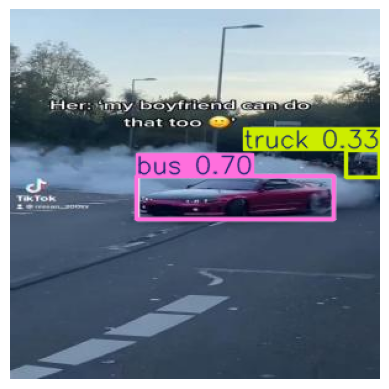

In [4]:
for object in results:
    im_array = object.plot()
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## libs to test with YouTube videos
- `pytubefix:` to download youtube videos
- `yt-dlp:` to handle with youtube link

In [5]:
%pip install pytubefix yt-dlp

Note: you may need to restart the kernel to use updated packages.


In [6]:
from pytubefix import YouTube

url = input('Youtube video URL: ')
yt = YouTube(url)

video_stream = yt.streams.filter(progressive=True, file_extension='mp4').order_by('resolution').desc().first()

video_path = video_stream.download(filename='video.mp4')
print(f'Video baixo com sucesso em: {video_path}')

Video baixo com sucesso em: /home/otonielnn/Desktop/uav-edge-intelligence/video.mp4


In [7]:
# Play the downloaded video
# 'show=True' will open a window showing the video with boxes in real-time
results = model.predict(source='video.mp4', show=True, conf=0.3)


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/312) /home/otonielnn/Desktop/uav-edge-intelligence/video.mp4: 384x640 10 cars, 5 buss, 1 truck, 68.4ms
video 1/1 (frame 2/312) /home/otonielnn/Desktop/uav-edge-intelligence/video.mp4: 384x640 10 cars, 5 buss, 1 truck, 76.7ms
video 1/1 (frame 3/312) /home/otonielnn/Desktop/uav-edge-intelligence/video.mp4: 384x640 12 cars, 5 buss, 86.5ms
video 1/1 (frame 4/312) /home/otonielnn/Desktop/uav-edge-intelligence/video.mp4: 384x640 10 cars, 4